# Importing Libraries

In [61]:
# Importing Libraries
import pandas as pd
import numpy as np
import os
import folium
import simplejson
import geopandas as gpd
import matplotlib.pyplot as plt

In [62]:
# Define the file path
path = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6'

# Correctly reading the pickle file
df_hap = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'df_happy_tested.pkl'))
df_inc = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'df_income.pkl'))

In [63]:
df_hap.shape

(2317, 14)

# Merging the datasets

In [64]:
# Merge df_happy_tested with df_income
df_merged_hapinc = pd.merge(df_hap, df_inc, on='Country name', how='inner', indicator=True)

In [65]:
print(df_merged_hapinc.head(5))

  Country name  year  Life Ladder  Log GDP per capita  Social support  \
0  Afghanistan  2008        3.724               7.350           0.451   
1  Afghanistan  2009        4.402               7.509           0.552   
2  Afghanistan  2010        4.758               7.614           0.539   
3  Afghanistan  2011        3.832               7.581           0.521   
4  Afghanistan  2012        3.783               7.661           0.521   

   Healthy life expectancy at birth  Freedom to make life choices  Generosity  \
0                              50.5                         0.718       0.164   
1                              50.8                         0.679       0.187   
2                              51.1                         0.600       0.118   
3                              51.4                         0.496       0.160   
4                              51.7                         0.531       0.234   

   Perceptions of corruption  Positive affect  Negative affect  \
0       

In [66]:
df_merged_hapinc.shape

(2055, 17)

In [67]:
num_countries1 = df_merged_hapinc['Country name'].nunique()
print(num_countries1)

146


# Wrangling the merged dataframe

In [68]:
# To check for nulls or NaNs
null_values = df_merged_hapinc.isnull().sum()
print("Null Values:\n", null_values)

Null Values:
 Country name                        0
year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
Positive affect                     0
Negative affect                     0
Happiness Score                     0
z_score                             0
Happiness Category                  0
Country Code                        0
IncomeGroup                         0
_merge                              0
dtype: int64


In [69]:
# Check for duplicate rows in the entire dataframe
duplicate_rows = df_merged_hapinc[df_merged_hapinc.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [Country name, year, Life Ladder, Log GDP per capita, Social support, Healthy life expectancy at birth, Freedom to make life choices, Generosity, Perceptions of corruption, Positive affect, Negative affect, Happiness Score, z_score, Happiness Category, Country Code, IncomeGroup, _merge]
Index: []


In [70]:
# Make a copy of df_merged_hapinc
df_copy = df_merged_hapinc.copy()

# Drop specified columns from df_copy
df_copy = df_copy.drop(columns=['_merge', 'Positive affect', 'Negative affect'], errors='ignore')

# Check the result
print(df_copy.head(2))

  Country name  year  Life Ladder  Log GDP per capita  Social support  \
0  Afghanistan  2008        3.724               7.350           0.451   
1  Afghanistan  2009        4.402               7.509           0.552   

   Healthy life expectancy at birth  Freedom to make life choices  Generosity  \
0                              50.5                         0.718       0.164   
1                              50.8                         0.679       0.187   

   Perceptions of corruption  Happiness Score   z_score Happiness Category  \
0                      0.882         1.904222 -0.698756      Low Happiness   
1                      0.850         2.858711 -0.579692      Low Happiness   

  Country Code IncomeGroup  
0          AFG  Low income  
1          AFG  Low income  


In [71]:
# Rename year to Year
df_copy.rename(columns={'year': 'Year'}, inplace=True)

In [72]:
# Get summary statistics for each numeric column
summary_stats = df_copy.describe()
print(summary_stats)

              Year  Life Ladder  Log GDP per capita  Social support  \
count  2055.000000  2055.000000         2055.000000     2055.000000   
mean   2014.734307     5.486032            9.394634        0.809204   
std       5.054567     1.127375            1.138240        0.122229   
min    2005.000000     1.281000            6.607000        0.228000   
25%    2011.000000     4.634500            8.511500        0.746000   
50%    2015.000000     5.472000            9.503000        0.836000   
75%    2019.000000     6.338500           10.366000        0.904000   
max    2023.000000     7.971000           11.676000        0.985000   

       Healthy life expectancy at birth  Freedom to make life choices  \
count                       2055.000000                   2055.000000   
mean                          63.344545                      0.752276   
std                            6.915995                      0.138529   
min                            6.720000                      0.22800

In [73]:
df_copy.columns

Index(['Country name', 'Year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Happiness Score', 'z_score',
       'Happiness Category', 'Country Code', 'IncomeGroup'],
      dtype='object')

# Create a Choropleth Map

In [74]:
geojson_path = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\joson_file\countries.geo.json'
print(f"File Exists: {os.path.exists(geojson_path)}")
print(f"Is File Readable: {os.access(geojson_path, os.R_OK)}")

File Exists: True
Is File Readable: True


Choropleth map saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Maps\choropleth_map.png


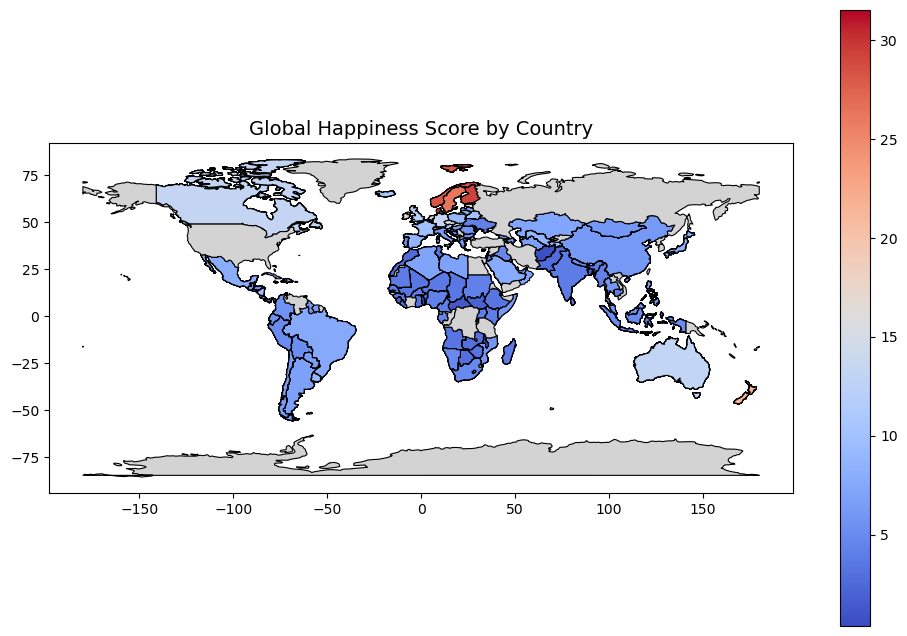

In [75]:
# Define the path to save the map
map_folder = os.path.join(path, 'Maps')
os.makedirs(map_folder, exist_ok=True)  # Create the folder if it doesn't exist
map_path = os.path.join(map_folder, 'choropleth_map.png')

# Load the GeoJSON file
url = 'https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json'
world = gpd.read_file(url)

# Ensure 'Country name' in df_copy matches the country column in the GeoDataFrame
df_copy = df_copy.rename(columns={'Country name': 'name'})

# Merge the data with the GeoDataFrame
merged = world.merge(df_copy, left_on='name', right_on='name', how='left')

# Plot the choropleth map using Happiness Score
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged.plot(column='Happiness Score', cmap='coolwarm', linewidth=0.8, edgecolor='black', 
            legend=True, ax=ax, missing_kwds={'color': 'lightgrey', 'label': 'No data'})

ax.set_title('Global Happiness Score by Country', fontsize=14)

# Save the map
plt.savefig(map_path, dpi=300, bbox_inches='tight')
print(f"Choropleth map saved successfully at: {map_path}")

# Show the plot
plt.show()

In [80]:
# Get the list of country names from the GeoJSON file
geojson_countries1 = set(world['name'])

# Get the list of country names from df_copy
df_countries = set(df_copy['name'])

# Find countries that are in df_copy but not in the GeoJSON file
non_matching_countries = df_countries - geojson_countries1

# Display the non-matching country names
print("Countries in df_copy that do not match the GeoJSON file:")
print(non_matching_countries)

Countries in df_copy that do not match the GeoJSON file:
{'Comoros', 'Czechia', 'Maldives', 'North Macedonia', 'Singapore', 'Serbia', 'Mauritius', 'Bahrain', 'Türkiye', 'United States', 'Tanzania', 'Eswatini'}


In [79]:
# Display all unique country names in the GeoJSON file
geojson_countries = sorted(world['name'].unique())

# Print the list
print("List of country names in the GeoJSON file:")
for country in geojson_countries:
    print(country)

List of country names in the GeoJSON file:
Afghanistan
Albania
Algeria
Angola
Antarctica
Argentina
Armenia
Australia
Austria
Azerbaijan
Bangladesh
Belarus
Belgium
Belize
Benin
Bermuda
Bhutan
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
Brunei
Bulgaria
Burkina Faso
Burundi
Cambodia
Cameroon
Canada
Central African Republic
Chad
Chile
China
Colombia
Costa Rica
Croatia
Cuba
Cyprus
Czech Republic
Democratic Republic of the Congo
Denmark
Djibouti
Dominican Republic
East Timor
Ecuador
Egypt
El Salvador
Equatorial Guinea
Eritrea
Estonia
Ethiopia
Falkland Islands
Fiji
Finland
France
French Guiana
French Southern and Antarctic Lands
Gabon
Gambia
Georgia
Germany
Ghana
Greece
Greenland
Guatemala
Guinea
Guinea Bissau
Guyana
Haiti
Honduras
Hungary
Iceland
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Ivory Coast
Jamaica
Japan
Jordan
Kazakhstan
Kenya
Kosovo
Kuwait
Kyrgyzstan
Laos
Latvia
Lebanon
Lesotho
Liberia
Libya
Lithuania
Luxembourg
Macedonia
Madagascar
Malawi
Malaysia
Mali
Malta
Mauritania
Me

In [89]:
num_countries = world['name'].nunique()
print(f"Number of unique countries in the world dataframe : {num_countries}")

Number of unique countries in the world dataframe : 180


In [82]:
# Rename Country Names in df_copy
df_copy['name'] = df_copy['name'].replace({
    'Czechia': 'Czech Republic',
    'Türkiye': 'Turkey',
    'United States': 'United States of America',
    'Eswatini': 'Swaziland',
    'North Macedonia': ' Macedonia'
})

# Creating a Vibrant map after changing few of the country names in df_copy

Choropleth map saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Maps\choropleth_map_vibrant.png


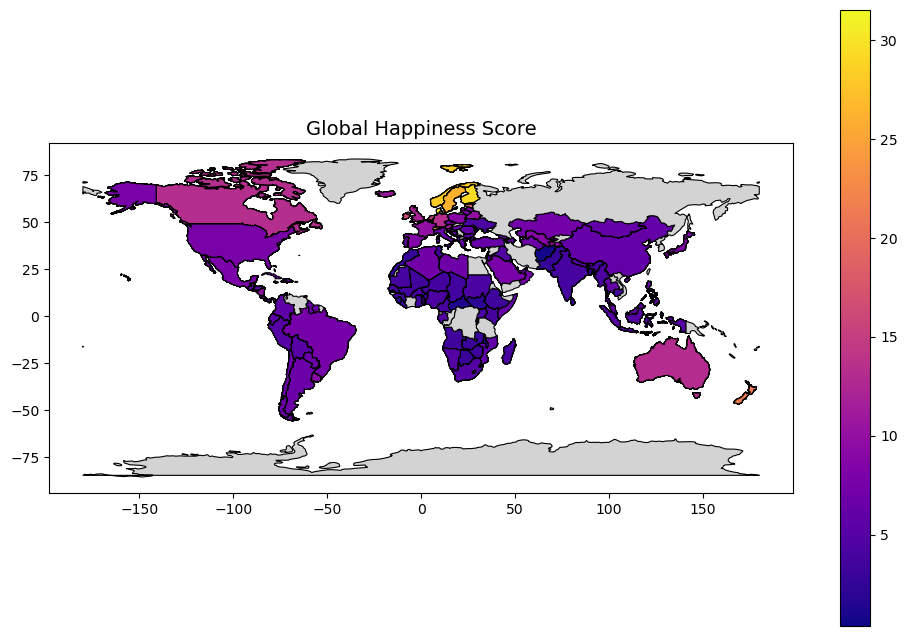

In [83]:
# Define the path to save the map
map_folder = os.path.join(path, 'Maps')
os.makedirs(map_folder, exist_ok=True)  # Create the folder if it doesn't exist
map_path = os.path.join(map_folder, 'choropleth_map_vibrant.png')

# Load the GeoJSON file
geojson_path = os.path.join(path, 'joson_file', 'countries.geo.json')
world = gpd.read_file(geojson_path)

# Ensure 'Country name' in df_copy matches the country column in the GeoDataFrame
df_copy = df_copy.rename(columns={'Country name': 'name'})

# Merge the data with the GeoDataFrame
merged = world.merge(df_copy, left_on='name', right_on='name', how='left')

# Plot the choropleth map using a more vibrant color palette ('plasma')
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged.plot(column='Happiness Score', cmap='plasma', linewidth=0.8, edgecolor='black', 
            legend=True, ax=ax, missing_kwds={'color': 'lightgrey', 'label': 'No data'})

ax.set_title('Global Happiness Score', fontsize=14)

# Save the map
plt.savefig(map_path, dpi=300, bbox_inches='tight')
print(f"Choropleth map saved successfully at: {map_path}")

# Show the plot
plt.show()

In [84]:
# Check the columns in the GeoDataFrame
print(world.columns)

# Check the first few rows to understand the structure
print(world.head())

Index(['id', 'name', 'geometry'], dtype='object')
    id                  name  \
0  AFG           Afghanistan   
1  AGO                Angola   
2  ALB               Albania   
3  ARE  United Arab Emirates   
4  ARG             Argentina   

                                            geometry  
0  POLYGON ((61.21082 35.65007, 62.23065 35.27066...  
1  MULTIPOLYGON (((16.32653 -5.87747, 16.57318 -6...  
2  POLYGON ((20.59025 41.8554, 20.46318 41.51509,...  
3  POLYGON ((51.57952 24.2455, 51.75744 24.29407,...  
4  MULTIPOLYGON (((-65.5 -55.2, -66.45 -55.25, -6...  


In [85]:
df_copy.columns

Index(['name', 'Year', 'Life Ladder', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy at birth', 'Freedom to make life choices',
       'Generosity', 'Perceptions of corruption', 'Happiness Score', 'z_score',
       'Happiness Category', 'Country Code', 'IncomeGroup'],
      dtype='object')

# Creating an Interactive map

In [86]:
# ---- Interactive Choropleth Map (Folium) ----

# Initialize the map centered on the world
m = folium.Map(location=[20, 0], zoom_start=2)

# Create a choropleth map using the original GeoJSON file for correct feature properties
folium.Choropleth(
    geo_data=geojson_path,  # Use the raw GeoJSON file to maintain feature properties
    data=merged,
    columns=['name', 'Happiness Score'],  
    key_on='feature.properties.name',  
    fill_color='plasma',  # More vibrant color scale
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Happiness Score'
).add_to(m)

# Save the interactive map as an HTML file
m.save(map_path_html)
print(f"Interactive choropleth map saved successfully at: {map_path_html}")

Interactive choropleth map saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Maps\happiness_map_interactive.html


# **Discussion of Results**  

The analysis provides valuable insights into global happiness scores and their distribution across countries. Due to a significant reduction in data after merging with the time-based dataset, I decided to exclude that data. As a result, the research questions have been slightly refined to focus on economic, social and governance factors that influence happiness.  

The findings highlight key relationships between economic prosperity, social structures, and happiness. Higher GDP per capita and better income group classifications are generally associated with higher happiness scores. Countries with strong social support systems and lower perceptions of corruption tend to report higher happiness levels. Additionally, factors such as healthcare (measured by healthy life expectancy) and personal freedom play a crucial role in shaping national well-being. The correlation between generosity and happiness also varies across economic groups, suggesting that social values and economic stability interact in complex ways.  

These insights provide a foundation for future research on how economic and social policies can be optimized to enhance national well-being.

# Saving the dataset

In [87]:
# Define the export path
export_path = os.path.join(path, 'Data', 'Prepared Data', 'df_revised.pkl')

# Save the merged dataframe as a pickle file
df_merged_hapinc.to_pickle(export_path)

print("File saved successfully at :", export_path)

File saved successfully at : C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Data\Prepared Data\df_revised.pkl
